In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    fcluster
)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix
)

In [5]:
features = pd.read_csv(
    r"C:\Users\INDIA\Data-Science-and-Machine-Learning-\ml\unsupervised_machine_learning\datasets\UCI HAR Dataset\features.txt",
    sep=r"\s+",
    header=None,
    names=["id", "feature"]
)

print(features.head())

   id            feature
0   1  tBodyAcc-mean()-X
1   2  tBodyAcc-mean()-Y
2   3  tBodyAcc-mean()-Z
3   4   tBodyAcc-std()-X
4   5   tBodyAcc-std()-Y


In [6]:
X_train = pd.read_csv(
    r"C:\Users\INDIA\Data-Science-and-Machine-Learning-\ml\unsupervised_machine_learning\datasets\UCI HAR Dataset\train\X_train.txt",
    sep=r"\s+",
    header=None
)

print(X_train.shape)

(7352, 561)


In [7]:
X_test = pd.read_csv(
    r"C:\Users\INDIA\Data-Science-and-Machine-Learning-\ml\unsupervised_machine_learning\datasets\UCI HAR Dataset\test\X_test.txt",
    sep=r"\s+",
    header=None
)

print(X_test.shape)

(2947, 561)


In [8]:
features_names = features["feature"].values
X_train.columns = features_names
X_test.columns = features_names

print(X_train.head())

   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.279174          -0.026201          -0.123283         -0.996091   
4           0.276629          -0.016570          -0.115362         -0.998139   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.983111         -0.913526         -0.995112         -0.983185   
1         -0.975300         -0.960322         -0.998807         -0.974914   
2         -0.967187         -0.978944         -0.996520         -0.963668   
3         -0.983403         -0.990675         -0.997099         -0.982750   
4         -0.980817         -0.990482         -0.998321         -0.979672   

   tBodyAcc-mad()-Z  tBodyAcc-max()-X  ...  fBodyBodyGyr

In [9]:
X=pd.concat(
    [
        X_train,
        X_test
    ],
    axis=0
).reset_index(drop=True)

print(X.shape)

(10299, 561)


In [10]:
y_train = pd.read_csv(
    r"C:\Users\INDIA\Data-Science-and-Machine-Learning-\ml\unsupervised_machine_learning\datasets\UCI HAR Dataset\train\y_train.txt",
    header=None,
    names=["Activity"]
)

y_test = pd.read_csv(
    r"C:\Users\INDIA\Data-Science-and-Machine-Learning-\ml\unsupervised_machine_learning\datasets\UCI HAR Dataset\test\y_test.txt",
    header=None,
    names=["Activity"]
)

In [11]:
y = pd.concat(
    [y_train, y_test],
    axis=0
).reset_index(drop=True)

In [12]:
print(y.head())

   Activity
0         5
1         5
2         5
3         5
4         5


In [14]:
activity_labels = pd.read_csv(
    r"C:\Users\INDIA\Data-Science-and-Machine-Learning-\ml\unsupervised_machine_learning\datasets\UCI HAR Dataset\activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["ActivityID", "Activity"]
)

print(activity_labels)

   ActivityID            Activity
0           1             WALKING
1           2    WALKING_UPSTAIRS
2           3  WALKING_DOWNSTAIRS
3           4             SITTING
4           5            STANDING
5           6              LAYING


In [15]:
print(X.isnull().sum().sum())

0


In [16]:
variances = X.var()

print(
    variances.sort_values().head(20)
)

tBodyAcc-mean()-Y                   0.001379
tBodyAcc-mean()-Z                   0.002813
fBodyAccJerk-bandsEnergy()-57,64    0.002872
fBodyGyro-bandsEnergy()-33,40       0.003409
fBodyGyro-bandsEnergy()-33,48       0.004187
fBodyGyro-bandsEnergy()-33,40       0.004357
tBodyAcc-mean()-X                   0.004574
fBodyGyro-bandsEnergy()-33,48       0.004626
fBodyGyro-bandsEnergy()-25,48       0.005098
fBodyGyro-bandsEnergy()-57,64       0.005126
tGravityAcc-iqr()-X                 0.005153
fBodyAccJerk-bandsEnergy()-33,40    0.005335
fBodyGyro-bandsEnergy()-49,64       0.005627
fBodyGyro-bandsEnergy()-25,32       0.005765
tGravityAcc-mad()-X                 0.005806
fBodyGyro-bandsEnergy()-57,64       0.005807
fBodyAcc-bandsEnergy()-33,40        0.005914
tGravityAcc-std()-X                 0.006040
fBodyAccJerk-bandsEnergy()-25,32    0.006199
fBodyAccJerk-bandsEnergy()-25,48    0.006295
dtype: float64


In [17]:
low_variance_features = variances[
    variances < 0.0001
].index

print(
    "Low variance features:",
    len(low_variance_features)
)

Low variance features: 0


In [18]:
X_reduced = X.drop(
    columns=low_variance_features
)

In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_reduced.to_numpy()
)

In [23]:
pca = PCA(
    n_components=0.90,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)

In [24]:
print(
    "Original features:",
    X_scaled.shape[1]
)

print(
    "PCA components:",
    X_pca.shape[1]
)

Original features: 561
PCA components: 65


In [25]:
print(
    "Explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance: 0.9004833346822926


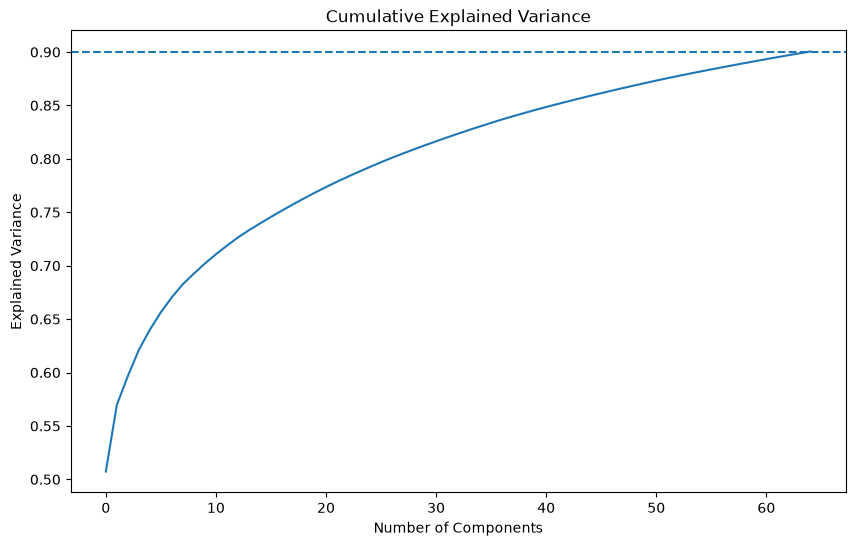

In [26]:
plt.figure(figsize=(10, 6))

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.plot(
    cumulative_variance
)

plt.axhline(
    0.90,
    linestyle="--"
)

plt.title(
    "Cumulative Explained Variance"
)

plt.xlabel(
    "Number of Components"
)

plt.ylabel(
    "Explained Variance"
)

plt.show()

In [27]:
pca_2d = PCA(
    n_components=2
)

X_2d = pca_2d.fit_transform(
    X_scaled
)

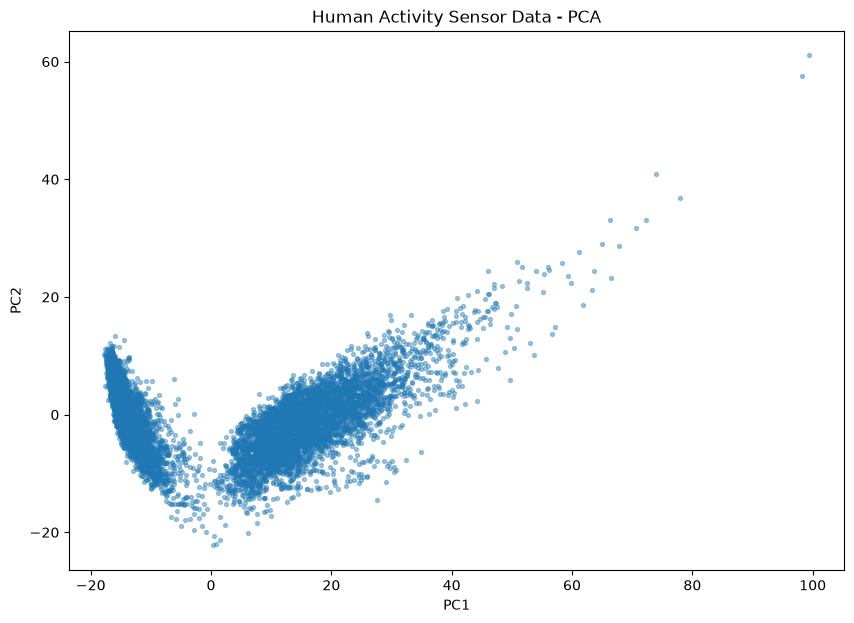

In [29]:

plt.figure(figsize=(10, 7))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    s=8,
    alpha=0.4
)

plt.title(
    "Human Activity Sensor Data - PCA"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [30]:
sample_size = 1000

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    len(X_pca),
    size=sample_size,
    replace=False
)

X_sample = X_pca[
    sample_indices
]

In [32]:
Z_ward = linkage(
    X_sample,
    method="ward"
)

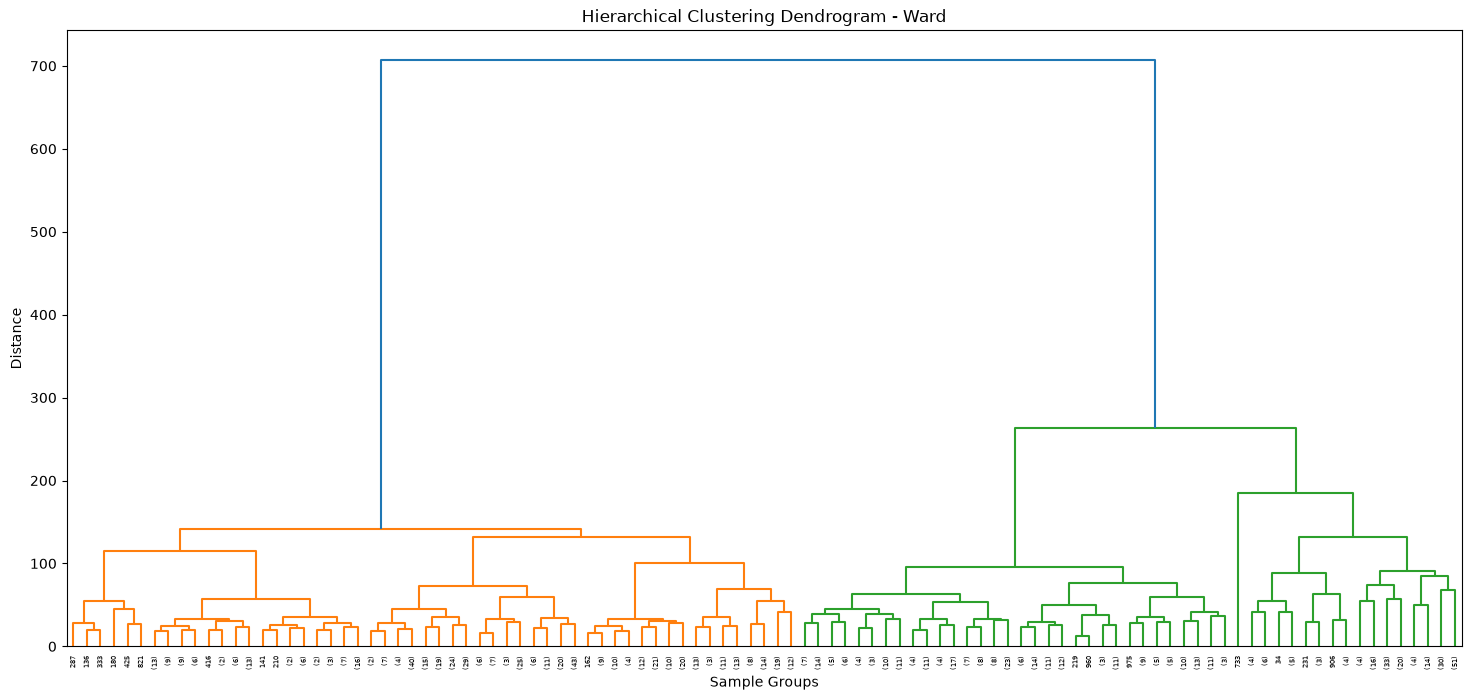

In [33]:
plt.figure(figsize=(18, 8))

dendrogram(
    Z_ward,
    truncate_mode="level",
    p=6
)

plt.title(
    "Hierarchical Clustering Dendrogram - Ward"
)

plt.xlabel("Sample Groups")

plt.ylabel("Distance")

plt.show()

In [34]:
sample_clusters = fcluster(
    Z_ward,
    t=6,
    criterion="maxclust"
)

In [35]:
print(
    np.unique(sample_clusters)
)

[1 2 3 4 5 6]


In [36]:
results = []

for k in range(2, 11):

    labels = fcluster(
        Z_ward,
        t=k,
        criterion="maxclust"
    )

    score = silhouette_score(
        X_sample,
        labels
    )

    results.append({
        "k": k,
        "silhouette": score
    })

results_df = pd.DataFrame(
    results
)

print(results_df)

    k  silhouette
0   2    0.433644
1   3    0.329186
2   4    0.329900
3   5    0.178523
4   6    0.173838
5   7    0.139180
6   8    0.137035
7   9    0.129197
8  10    0.083864


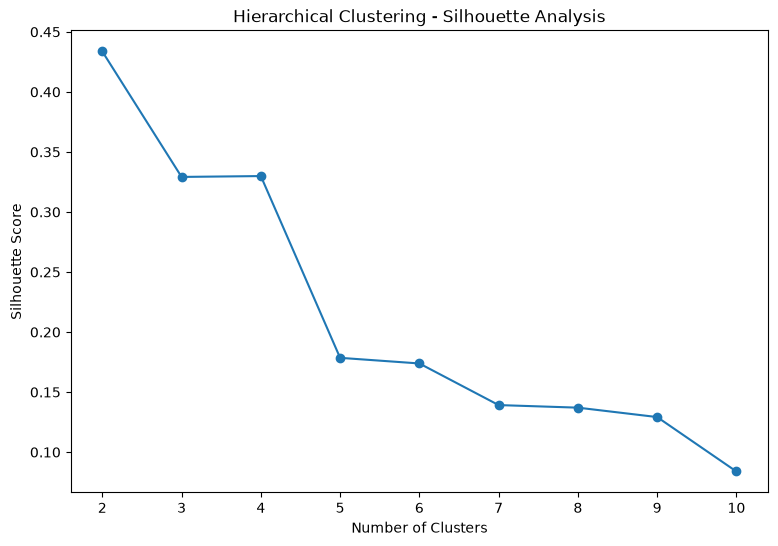

In [37]:
plt.figure(figsize=(9, 6))

plt.plot(
    results_df["k"],
    results_df["silhouette"],
    marker="o"
)

plt.title(
    "Hierarchical Clustering - Silhouette Analysis"
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "Silhouette Score"
)

plt.show()

    Linkage  Silhouette
0      ward    0.173838
1  complete    0.410924
2   average    0.374809


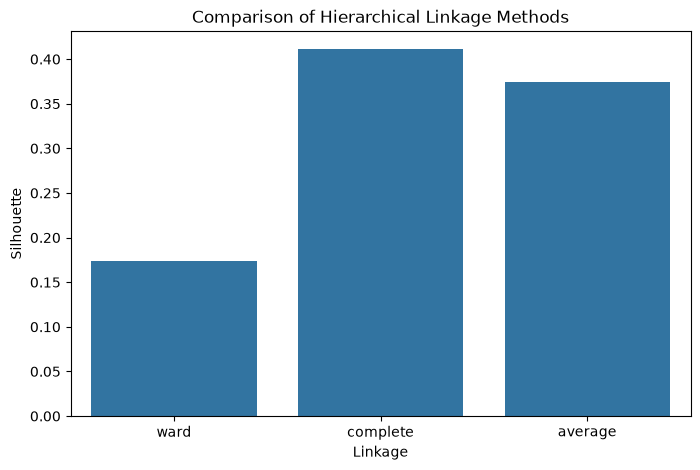

In [38]:
linkage_methods = [
    "ward",
    "complete",
    "average"
]

linkage_results = []

for method in linkage_methods:

    Z = linkage(
        X_sample,
        method=method
    )

    labels = fcluster(
        Z,
        t=6,
        criterion="maxclust"
    )

    score = silhouette_score(
        X_sample,
        labels
    )

    linkage_results.append({
        "Linkage": method,
        "Silhouette": score
    })

linkage_df = pd.DataFrame(
    linkage_results
)

print(linkage_df)



plt.figure(figsize=(8, 5))

sns.barplot(
    data=linkage_df,
    x="Linkage",
    y="Silhouette"
)

plt.title(
    "Comparison of Hierarchical Linkage Methods"
)

plt.show()

In [39]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=6,
    linkage="ward"
)

clusters = hierarchical_model.fit_predict(
    X_pca
)

In [40]:
X_result = X.copy()

X_result["Cluster"] = clusters

print(
    X_result["Cluster"].value_counts()
    .sort_index()
)

Cluster
0    2281
1    3465
2    2241
3     150
4    1675
5     487
Name: count, dtype: int64


In [41]:
visual_df = pd.DataFrame(
    X_2d,
    columns=["PC1", "PC2"]
)

visual_df["Cluster"] = clusters

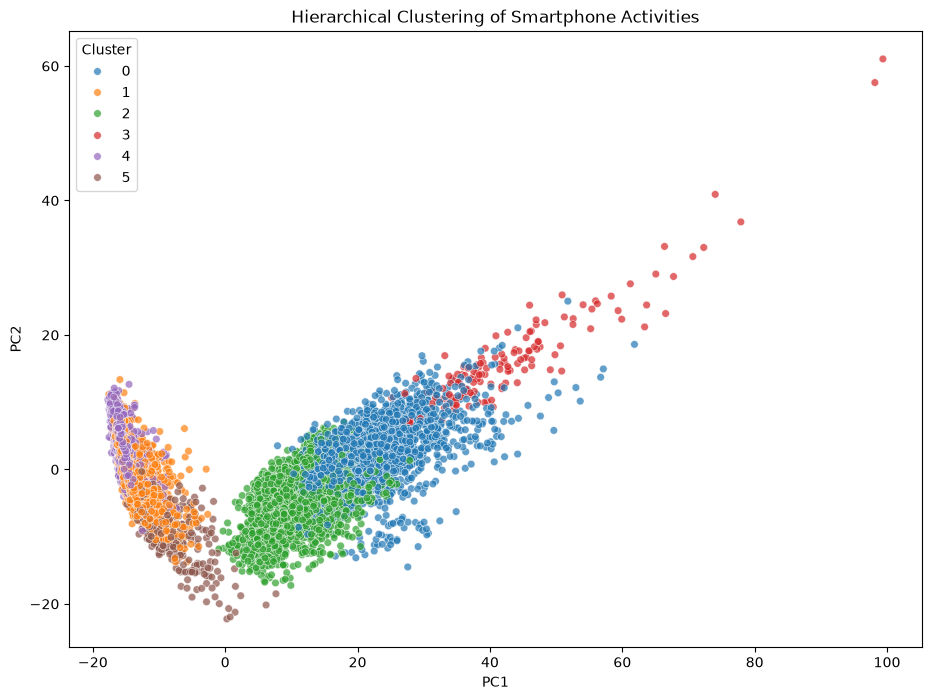

In [42]:
plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=visual_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=30,
    alpha=0.7
)

plt.title(
    "Hierarchical Clustering of Smartphone Activities"
)

plt.show()

Here is a concise prompt/description you can paste into another AI system to generate the same project:

Build an advanced, production-style **Unsupervised Machine Learning project using Hierarchical (Agglomerative) Clustering** with the real **UCI Human Activity Recognition Using Smartphones (HAR)** dataset.

Use the dataset's 10,299 sensor observations and 561 features generated from smartphone accelerometer and gyroscope signals. The project should discover natural human movement patterns without using the provided activity labels during clustering.

Include complete Python code and explanations for: dataset loading and exploration, feature-name loading, missing-value and duplicate checks, low-variance feature filtering, statistical analysis, visualizations, correlation analysis, StandardScaler preprocessing, PCA dimensionality reduction, explained-variance analysis, hierarchical clustering with Ward/Complete/Average linkage, dendrogram visualization, optimal cluster selection using silhouette scores, AgglomerativeClustering, PCA-based cluster visualization, cluster-size analysis, and detailed cluster interpretation.

For advanced evaluation, keep the original activity labels completely separate from model training and use them only after clustering to compare discovered clusters with actual activities. Include Adjusted Rand Index (ARI), Normalized Mutual Information (NMI), cluster-vs-activity heatmaps, and activity distribution analysis.

Also implement a realistic inference workflow for a new unseen smartphone sensor observation. Apply the exact same preprocessing and PCA transformations, calculate its distance from learned cluster representatives, assign it to the nearest cluster, and interpret the cluster based on its dominant activity pattern. Explain that standard AgglomerativeClustering does not provide a native `predict()` method like K-Means.

Use pandas, NumPy, Matplotlib, Seaborn, SciPy, and scikit-learn. Provide the dataset download link, project folder structure, installation commands, complete step-by-step code, visualizations, evaluation metrics, interpretation, model-saving approach, and a production-style ML workflow/API concept. The project should be practical, detailed, and suitable for an advanced machine-learning portfolio project.
